# Mini Projeto Integrador - Parte 1

Simulação de um Sistema de Aquisição e Processamento de Sinais de Áudio.

### Etapas 1 e 2: Escolha do Fenômeno e Geração Computacional
O fenômeno acústico escolhido é um acorde musical simples composto por duas notas distintas (Lá e Dó sustenido) tocadas em simultâneo.
O modelo matemático é dado por:
$$x(t) = A_1 \cos(2\pi f_1 t) + A_2 \cos(2\pi f_2 t)$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# parâmetros do sinal de áudio
f1 = 440.0  # Nota Lá - A4
f2 = 554.0  # Nota Dó# - C#5
A1 = 1.0
A2 = 0.6
fase = 0

# intervalo de observação (10 milissegundos)
t_limite = 0.01 

t_continuo = np.linspace(0, t_limite, 2000)
x_continuo = A1 * np.cos(2 * np.pi * f1 * t_continuo + fase) + \
             A2 * np.cos(2 * np.pi * f2 * t_continuo + fase)

### Etapa 3: Amostragem
Para digitalizar o sinal contínuo, definiu-se a frequência de amostragem $f_s = 8000$ Hz. O período de amostragem resulta em $T_s = 1/8000 = 0,000125$ s. O sinal discretizado é obtido por $x[n] = x(nT_s)$.

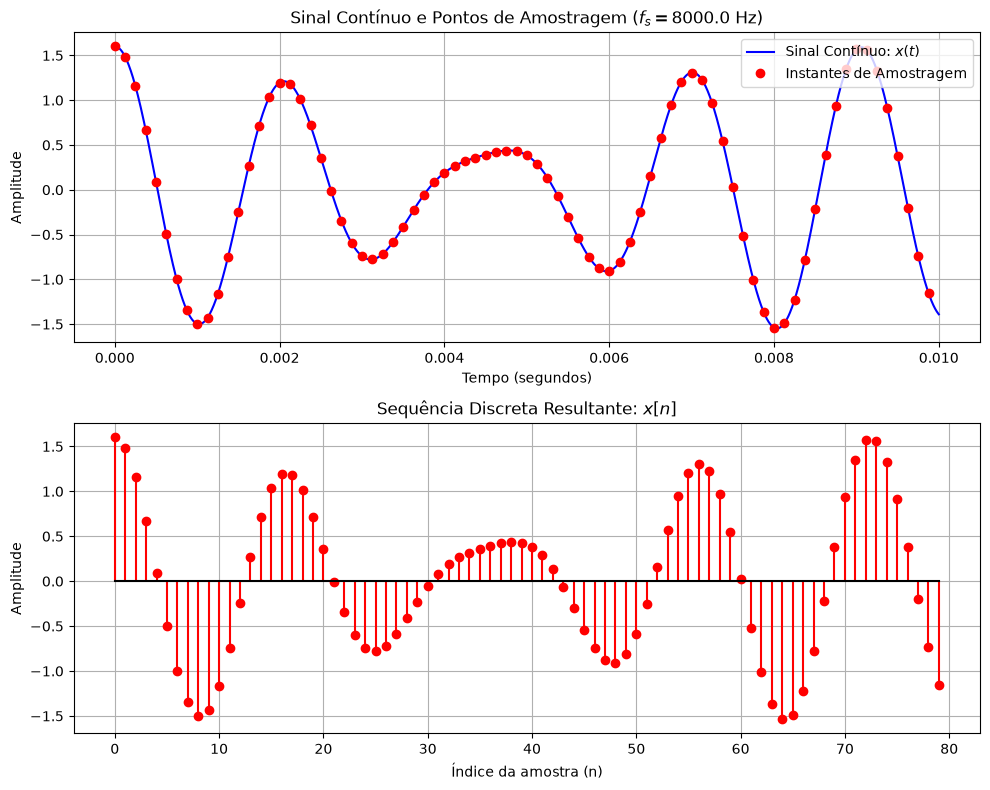

In [ ]:
# amostragem
fs = 8000.0  
Ts = 1 / fs  

# eixo temporal discreto
t_discreto = np.arange(0, t_limite, Ts)
n_amostras = np.arange(len(t_discreto)) 

# sinal discretizado
x_discreto = A1 * np.cos(2 * np.pi * f1 * t_discreto + fase) + \
             A2 * np.cos(2 * np.pi * f2 * t_discreto + fase)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(t_continuo, x_continuo, 'b-', label='Sinal Contínuo: $x(t)$')
axes[0].plot(t_discreto, x_discreto, 'ro', label='Instantes de Amostragem')
axes[0].set_title(rf'Sinal Contínuo e Pontos de Amostragem ($f_s = {fs}$ Hz)')
axes[0].set_xlabel('Tempo (segundos)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend(loc='upper right')

axes[1].stem(n_amostras, x_discreto, linefmt='r-', markerfmt='ro', basefmt='k-')
axes[1].set_title(r'Sequência Discreta Resultante: $x[n]$')
axes[1].set_xlabel('Índice da amostra (n)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Etapa 4: Quantização
O sinal amostrado será quantizado para limitar a sua amplitude a níveis discretos. Simularemos um ADC com excursão de -2V a +2V (faixa de 4V) testando duas resoluções: $N_1 = 4$ bits e $N_2 = 8$ bits.

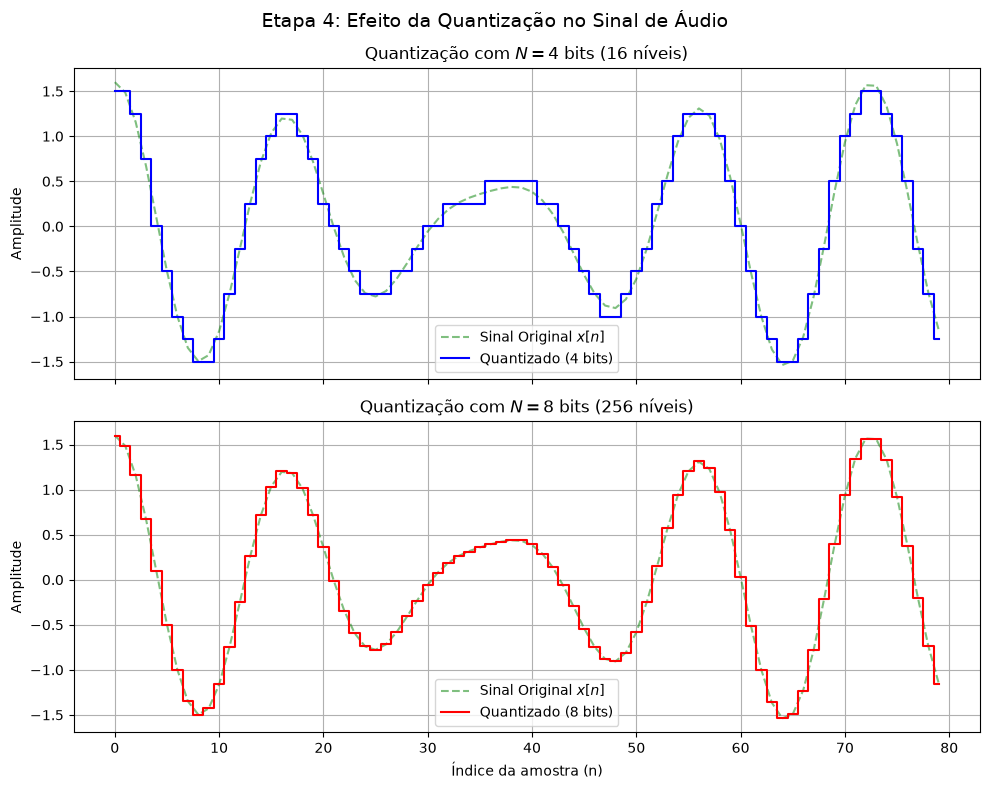

In [5]:
# faixa de operação do ADC
excursao = 4.0

# quantização com N = 4 bits
L_4 = 2**4
delta_4 = excursao / L_4
x_quant_4 = np.round(x_discreto / delta_4) * delta_4

# quantização com N = 8 bits
L_8 = 2**8
delta_8 = excursao / L_8
x_quant_8 = np.round(x_discreto / delta_8) * delta_8

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle('Etapa 4: Efeito da Quantização no Sinal de Áudio', fontsize=14)

axes[0].plot(n_amostras, x_discreto, 'g--', alpha=0.5, label='Sinal Original $x[n]$')
axes[0].step(n_amostras, x_quant_4, 'b-', where='mid', label='Quantizado (4 bits)')
axes[0].set_title(r'Quantização com $N = 4$ bits (16 níveis)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(n_amostras, x_discreto, 'g--', alpha=0.5, label='Sinal Original $x[n]$')
axes[1].step(n_amostras, x_quant_8, 'r-', where='mid', label='Quantizado (8 bits)')
axes[1].set_title(r'Quantização com $N = 8$ bits (256 níveis)')
axes[1].set_xlabel('Índice da amostra (n)')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Etapa 5: Inclusão de Ruído
Adição de ruído branco gaussiano para simular o chiado térmico de um pré-amplificador de microfone. O sinal resultante é $x_r[n] = x[n] + r[n]$.

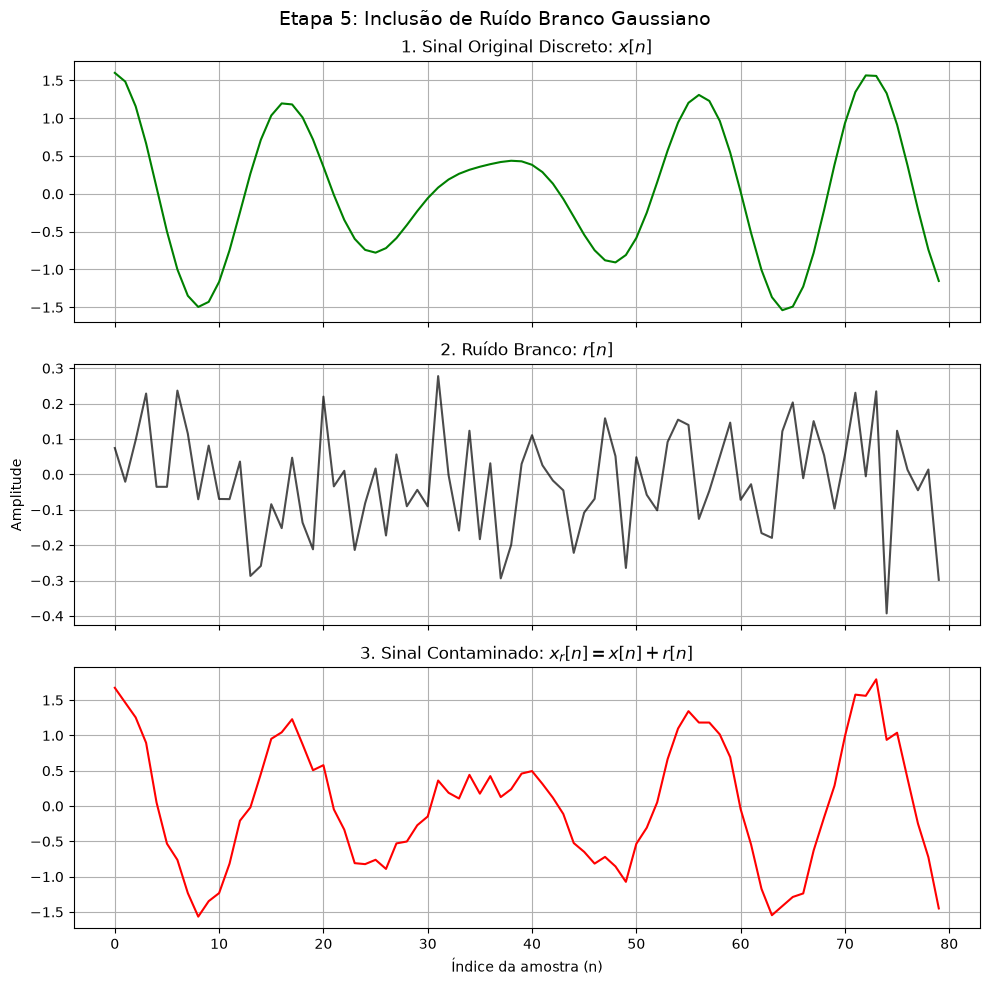

In [6]:
# geração do ruído
np.random.seed(42)
ruido = 0.15 * np.random.randn(len(x_discreto))

# sinal contaminado
xr_discreto = x_discreto + ruido

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Etapa 5: Inclusão de Ruído Branco Gaussiano', fontsize=14)

axes[0].plot(n_amostras, x_discreto, 'g-')
axes[0].set_title('1. Sinal Original Discreto: $x[n]$')
axes[0].grid(True)

axes[1].plot(n_amostras, ruido, 'k-', alpha=0.7)
axes[1].set_title('2. Ruído Branco: $r[n]$')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True)

axes[2].plot(n_amostras, xr_discreto, 'r-')
axes[2].set_title('3. Sinal Contaminado: $x_r[n] = x[n] + r[n]$')
axes[2].set_xlabel('Índice da amostra (n)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

### Etapa 6: Processamento LTI
O sinal ruidoso será processado por um sistema LTI (filtro de média móvel) com janela de $M=5$.

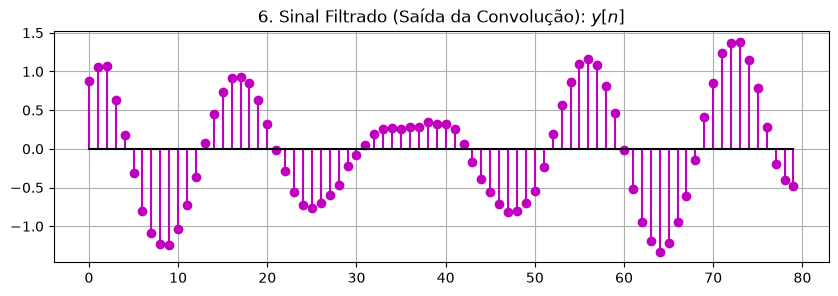

In [23]:
# sistema LTI
M = 5
h_n = np.ones(M) / M

# convolução
y_n = np.convolve(xr_discreto, h_n, mode='same')

plt.figure(figsize=(10, 3))
plt.stem(n_amostras, y_n, linefmt='m-', markerfmt='mo', basefmt='k-')
plt.title(r'6. Sinal Filtrado (Saída da Convolução): $y[n]$')
plt.grid(True)
plt.show()


### Etapa 7: Comparação dos resultados

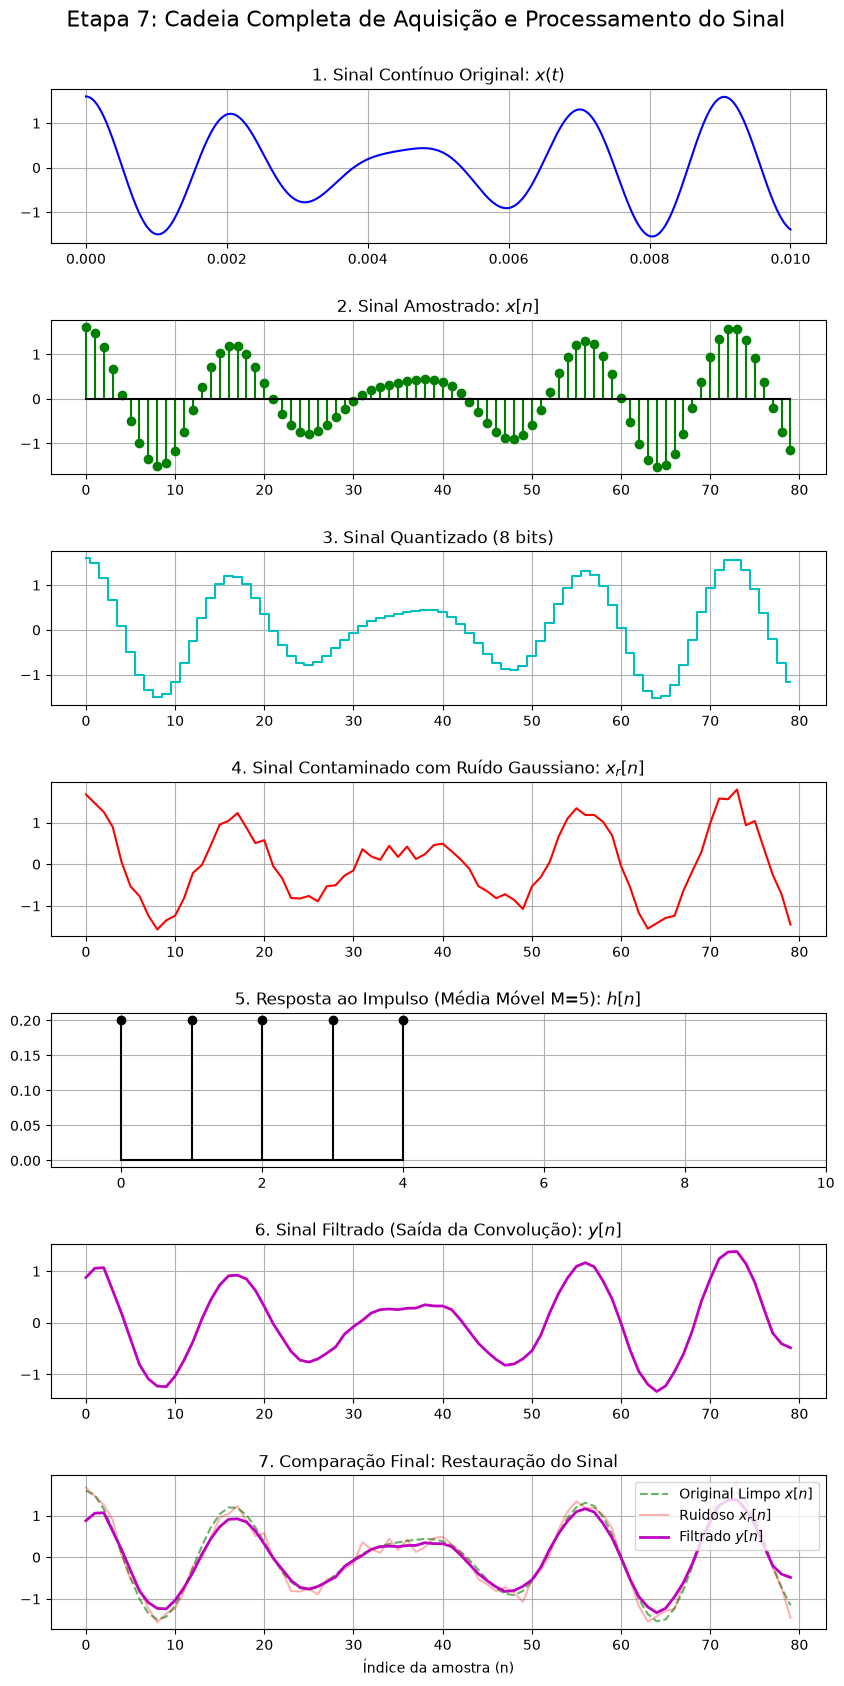

In [12]:
# comparação dos resultados
fig, axes = plt.subplots(7, 1, figsize=(10, 20), sharex=False)
fig.suptitle('Etapa 7: Cadeia Completa de Aquisição e Processamento do Sinal', fontsize=16, y=0.92)

# sinal original
axes[0].plot(t_continuo, x_continuo, 'b-')
axes[0].set_title('1. Sinal Contínuo Original: $x(t)$')
axes[0].grid(True)

# sinal amostrado
axes[1].stem(n_amostras, x_discreto, linefmt='g-', markerfmt='go', basefmt='k-')
axes[1].set_title('2. Sinal Amostrado: $x[n]$')
axes[1].grid(True)

# sinal quantizado
axes[2].step(n_amostras, x_quant_8, 'c-', where='mid')
axes[2].set_title('3. Sinal Quantizado (8 bits)')
axes[2].grid(True)

# sinal com ruído
axes[3].plot(n_amostras, xr_discreto, 'r-')
axes[3].set_title('4. Sinal Contaminado com Ruído Gaussiano: $x_r[n]$')
axes[3].grid(True)

# resposta ao impulso
n_h = np.arange(len(h_n))
axes[4].stem(n_h, h_n, linefmt='k-', markerfmt='ko', basefmt='k-')
axes[4].set_title(f'5. Resposta ao Impulso (Média Móvel M={M}): $h[n]$')
axes[4].set_xlim(-1, 10)
axes[4].grid(True)

# sinal após a convolução
axes[5].plot(n_amostras, y_n, 'm-', linewidth=2)
axes[5].set_title('6. Sinal Filtrado (Saída da Convolução): $y[n]$')
axes[5].grid(True)

# comparação entrada vs saída
axes[6].plot(n_amostras, x_discreto, 'g--', alpha=0.6, label='Original Limpo $x[n]$')
axes[6].plot(n_amostras, xr_discreto, 'r-', alpha=0.3, label='Ruidoso $x_r[n]$')
axes[6].plot(n_amostras, y_n, 'm-', linewidth=2, label='Filtrado $y[n]$')
axes[6].set_title('7. Comparação Final: Restauração do Sinal')
axes[6].set_xlabel('Índice da amostra (n)')
axes[6].legend(loc='upper right')
axes[6].grid(True)

plt.subplots_adjust(hspace=0.5)
plt.show()